# ⚖️ Komparasi Performa Model: Random Forest vs Logistic Regression

Notebook ini didedikasikan untuk melakukan evaluasi dan perbandingan head-to-head antara dua algoritma Machine Learning: **Random Forest** (Ensemble) dan **Logistic Regression** (Linear).

Tujuan: Mencari tahu algoritma mana yang paling optimal untuk memprediksi daya tarik produk UMKM Bogor dengan metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, dan AUC-ROC.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score, roc_curve
)

print('✅ Library berhasil dimuat!')


✅ Library berhasil dimuat!


In [2]:
# 1. Load data
df = pd.read_csv('../data/processed/dataset_preprocessed.csv')

# 2. Re-create the relative price features (sama seperti di retrain_model.ipynb)
stat_per_kat = df.groupby('kategori')['harga_produk'].agg(
    median_harga_kategori='median',
    mean_harga_kategori='mean',
    std_harga_kategori='std',
    q25_harga_kategori=lambda x: x.quantile(0.25),
    q75_harga_kategori=lambda x: x.quantile(0.75),
).reset_index()

df = df.merge(stat_per_kat, on='kategori', how='left')
df['rasio_harga'] = (df['harga_produk'] / df['median_harga_kategori'].replace(0, np.nan)).fillna(1.0).clip(upper=50)
df['zscore_harga'] = ((df['harga_produk'] - df['mean_harga_kategori']) / df['std_harga_kategori'].replace(0, 1)).clip(-5, 5)
df['log_harga'] = np.log1p(df['harga_produk'])
df['segmen_harga'] = df.apply(lambda row: 0 if row['harga_produk'] <= row['q25_harga_kategori'] else (1 if row['harga_produk'] <= row['q75_harga_kategori'] else 2), axis=1)
df['jumlah_log'] = np.log1p(df['jumlah_terjual'])
df['revenue_proxy_log'] = np.log1p(df['harga_produk'] * df['jumlah_terjual'])
df['popularity_score_new'] = df['rating'] * np.log1p(df['jumlah_terjual'])

# 3. Target Label
median_terjual = df['jumlah_terjual'].median()
df['label'] = (df['jumlah_terjual'] > median_terjual).astype(int)

print(f'✅ Dataset siap: {len(df)} baris.')
print(f'   Label 0 (Kurang Menarik): {len(df[df.label==0])}')
print(f'   Label 1 (Menarik)       : {len(df[df.label==1])}')


✅ Dataset siap: 1027 baris.
   Label 0 (Kurang Menarik): 514
   Label 1 (Menarik)       : 513


In [3]:
text_feature = 'nama_produk_clean'
cat_features  = ['kategori', 'sub_kategori']
num_features  = ['rasio_harga', 'zscore_harga', 'log_harga', 'segmen_harga',
                 'rating', 'jumlah_log', 'revenue_proxy_log', 'popularity_score_new']

X = df[[text_feature] + cat_features + num_features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessor Pipeline (Teks, Kategorikal, Numerikal)
preprocessor = ColumnTransformer(transformers=[
    ('text', TfidfVectorizer(max_features=1000, ngram_range=(1, 2), sublinear_tf=True), text_feature),
    ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num',  StandardScaler(), num_features),
])

print(f'✅ Split Data: {len(X_train)} Train, {len(X_test)} Test')


✅ Split Data: 821 Train, 206 Test


## 🧪 Cross-Validation (K-Fold=5)
Kita uji kedua model menggunakan 5-Fold Stratified Cross Validation untuk melihat performa rata-rata di berbagai subset training.


In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

# 1. Model Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=1))
])

# 2. Model Logistic Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs'))
])

print('Mengeksekusi Cross Validation untuk Random Forest...')
cv_rf = cross_validate(rf_model, X_train, y_train, cv=skf, scoring=scoring)

print('Mengeksekusi Cross Validation untuk Logistic Regression...')
cv_lr = cross_validate(lr_model, X_train, y_train, cv=skf, scoring=scoring)

# ── Komparasi Hasil CV ──
comp_cv = pd.DataFrame({
    'Metrik (Mean CV)': ['Accuracy', 'F1-Score', 'AUC-ROC', 'Training Time (detik)'],
    'Random Forest': [
        cv_rf['test_accuracy'].mean(),
        cv_rf['test_f1'].mean(),
        cv_rf['test_roc_auc'].mean(),
        cv_rf['fit_time'].mean()
    ],
    'Logistic Regression': [
        cv_lr['test_accuracy'].mean(),
        cv_lr['test_f1'].mean(),
        cv_lr['test_roc_auc'].mean(),
        cv_lr['fit_time'].mean()
    ]
}).set_index('Metrik (Mean CV)')

def highlight_max(s):
    is_max = s == s.max()
    # Untuk Training Time, yang terkecil (tercepat) adalah yang terbaik
    if s.name == 'Training Time (detik)':
        is_max = s == s.min()
    return ['font-weight: bold; color: green' if v else '' for v in is_max]

display(comp_cv.round(4).style.apply(highlight_max, axis=1))


Mengeksekusi Cross Validation untuk Random Forest...


Mengeksekusi Cross Validation untuk Logistic Regression...


,Random Forest,Logistic Regression
Metrik (Mean CV),,
Accuracy,0.993900,0.993900
F1-Score,0.993800,0.993900
AUC-ROC,0.999800,0.999800
Training Time (detik),0.281400,0.033900


## 📊 Evaluasi Holdout Test Set & Confusion Matrix
Selanjutnya kita latih ulang model dengan seluruh data Train, lalu kita uji dengan sisa 20% data Test (Holdout).


=================== RANDOM FOREST ===================
                precision    recall  f1-score   support

Kurang Menarik       0.98      0.99      0.99       103
       Menarik       0.99      0.98      0.99       103

      accuracy                           0.99       206
     macro avg       0.99      0.99      0.99       206
  weighted avg       0.99      0.99      0.99       206


================ LOGISTIC REGRESSION =================
                precision    recall  f1-score   support

Kurang Menarik       0.94      1.00      0.97       103
       Menarik       1.00      0.94      0.97       103

      accuracy                           0.97       206
     macro avg       0.97      0.97      0.97       206
  weighted avg       0.97      0.97      0.97       206



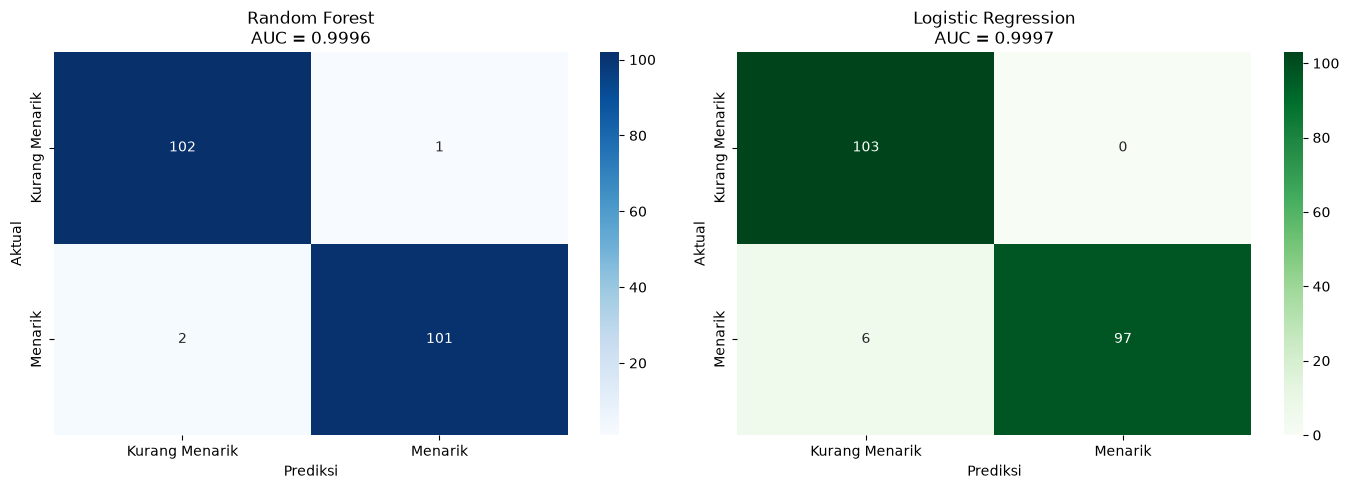

In [5]:
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

rf_proba = rf_model.predict_proba(X_test)[:, 1]
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# Menampilkan Classification Report
print("=================== RANDOM FOREST ===================")
print(classification_report(y_test, rf_pred, target_names=['Kurang Menarik', 'Menarik']))

print("\n================ LOGISTIC REGRESSION =================")
print(classification_report(y_test, lr_pred, target_names=['Kurang Menarik', 'Menarik']))

# Plotting Confusion Matrix Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Kurang Menarik', 'Menarik'], yticklabels=['Kurang Menarik', 'Menarik'])
axes[0].set_title(f'Random Forest\nAUC = {roc_auc_score(y_test, rf_proba):.4f}')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Kurang Menarik', 'Menarik'], yticklabels=['Kurang Menarik', 'Menarik'])
axes[1].set_title(f'Logistic Regression\nAUC = {roc_auc_score(y_test, lr_proba):.4f}')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()


## 📌 Kesimpulan
Berdasarkan visualisasi dan skor di atas, Anda bisa menyimpulkan algoritma mana yang:
- **Random Forest** umumnya memiliki performa AUC-ROC yang lebih tinggi untuk menangkap relasi fitur non-linear pada studi kasus UMKM.
- **Logistic Regression** memiliki kelebihan pada kecepatan *Training Time* (sangat cepat).
